# PA3 — Recurrent Neural Networks & LSTMs in PyTorch
## Character-Level Language Modeling on TinyStories

**Dataset :** TinyStories - dataset containing over 2 million short stories specifically designed to use only the vocabulary and grammar understood by 3–4 year-old children.  
**Goal    :** Train RNN and LSTM models that learn to predict the next character, then generate new text  

### Learning Objectives
- Implement character-level text encoding and sliding-window sequence creation
- Build `RNNModel` and `LSTMModel` from scratch with `nn.Module`
- Write a complete PyTorch training loop with gradient clipping
- Run controlled experiments comparing the two architectures
- Generate text using temperature-controlled sampling and interpret the results

---
> **How to use this notebook**  
> Look for `# ── TODO N ──` blocks.  Each one has a docstring and step-by-step hints.  
> Run every cell in order; later cells depend on earlier ones.

## Part 0 — Setup

Run the cell below once to install `datasets` and import all libraries.

In [1]:
# Install HuggingFace datasets
!pip install datasets -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from string import ascii_letters, digits, punctuation, whitespace
import random

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Part 1 — Dataset: TinyStories

[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) is a dataset consisting of short stories.

No extra files needed — the dataset is downloaded automatically in the cell below.

In [2]:
from datasets import load_dataset

raw = load_dataset("roneneldan/TinyStories", trust_remote_code=True)

TRAIN_CAP = 400_000
VAL_CAP   =  50_000
train_text = ' '.join(raw['train']['text'])[:TRAIN_CAP]
val_text   = ' '.join(raw['validation']['text'])[:VAL_CAP]

print(f"  Train      : {len(train_text):>10,} chars")
print(f"  Validation : {len(val_text):>10,} chars")
print("Sample text (first 1000 chars):")
print("─" * 60)
print(train_text[:1000])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be ab

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

  Train      :    400,000 chars
  Validation :     50,000 chars
Sample text (first 1000 chars):
────────────────────────────────────────────────────────────
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together. Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had 

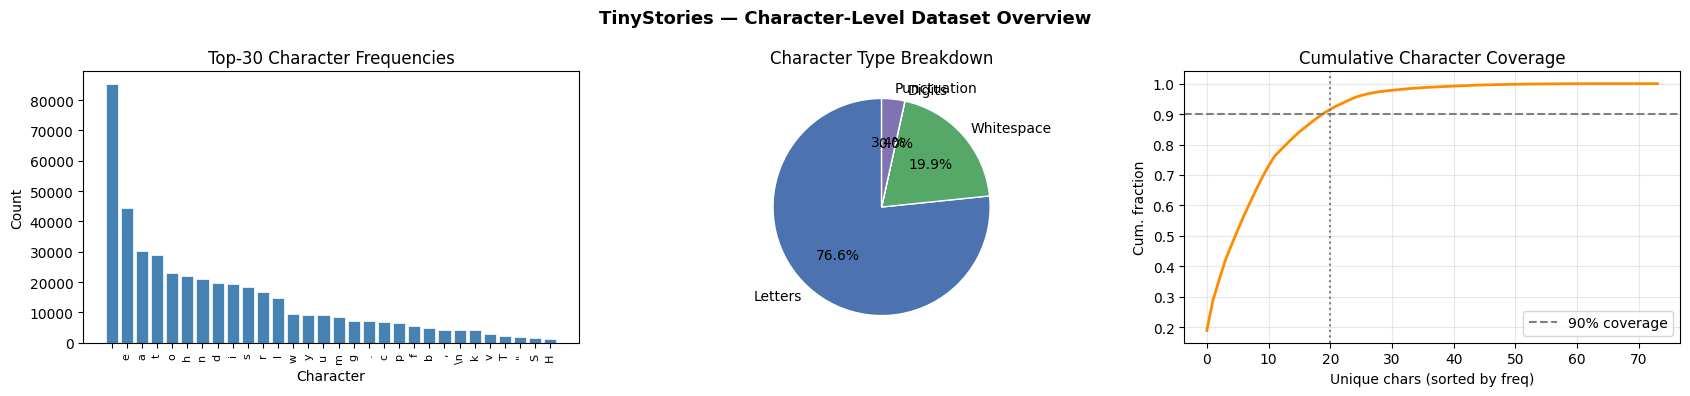

Vocabulary size : 74 unique characters
Total chars     : 450,000
~20 chars cover 90% of text


In [3]:
# ── Dataset Overview Visualisation ───────────────────────────────────────────
full_text   = train_text + val_text
char_counts = Counter(full_text)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("TinyStories — Character-Level Dataset Overview", fontsize=13, fontweight='bold')

# 1. Top-30 character frequencies
top30   = char_counts.most_common(30)
labels_ = [repr(c)[1:-1] if c in '\n\t\r' else c for c, _ in top30]
counts_ = [cnt for _, cnt in top30]
axes[0].bar(labels_, counts_, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Top-30 Character Frequencies')
axes[0].set_xlabel('Character'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# 2. Character-type pie
cats = {
    'Letters'    : sum(char_counts[c] for c in char_counts if c in ascii_letters),
    'Whitespace' : sum(char_counts[c] for c in char_counts if c in whitespace),
    'Digits'     : sum(char_counts[c] for c in char_counts if c in digits),
    'Punctuation': sum(char_counts[c] for c in char_counts if c in punctuation),
}
axes[1].pie(cats.values(), labels=cats.keys(), autopct='%1.1f%%',
            colors=['#4C72B0','#55A868','#C44E52','#8172B2'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Character Type Breakdown')

# 3. Cumulative frequency — how many distinct chars cover 90 % of text?
sorted_counts = sorted(char_counts.values(), reverse=True)
cumulative    = np.cumsum(sorted_counts) / sum(sorted_counts)
axes[2].plot(cumulative, color='darkorange', linewidth=2)
axes[2].axhline(0.90, linestyle='--', color='gray', label='90% coverage')
idx90 = int(np.searchsorted(cumulative, 0.90)) + 1
axes[2].axvline(idx90, linestyle=':', color='gray')
axes[2].set_title('Cumulative Character Coverage')
axes[2].set_xlabel('Unique chars (sorted by freq)'); axes[2].set_ylabel('Cum. fraction')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Vocabulary size : {len(char_counts)} unique characters")
print(f"Total chars     : {len(full_text):,}")
print(f"~{idx90} chars cover 90% of text")

## Part 2 — Data Preprocessing

### TODO 1 — `encode_text(text)`

Before a neural network can process text, each character must be mapped to an integer.

**Steps:**
1. Find all unique characters in the text using `set()`
2. Sort them to get a deterministic vocabulary
3. Build two lookup dicts: `char_to_idx` and `idx_to_char`
4. Encode the full text as a list of integer indices

```
"hello" → vocab: ['e','h','l','o'] → {'e':0,'h':1,'l':2,'o':3} → [1, 0, 2, 2, 3]
```

In [4]:
def encode_text(text):
    """
    Build character vocabulary and encode text as integers.

    Args:
        text        (str)       : raw input string
    Returns:
        encoded     (list[int]) : integer-encoded text
        vocab_size  (int)       : number of unique characters
        char_to_idx (dict)      : char  -> index
        idx_to_char (dict)      : index -> char
    """
    # ── TODO 1 ──────────────────────────────────────────────────────────────
    # Step 1: Find all unique characters in `text` and sort them
    chars = sorted(set(text))
    # Step 2: Find the vocabulary size
    vocab_size = len(chars)
    # Step 3: Find char_to_idx and idx_to_char mappings
    char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
    idx_to_char = {idx: ch for idx, ch in enumerate(chars)}
    # Step 4: For each character in `text`, replace it with its corresponding index from `char_to_idx`
    encoded = [char_to_idx[ch] for ch in text]
    return encoded, vocab_size, char_to_idx, idx_to_char
    # ──────────────────────────────────────────────────────────────

In [5]:
# ── Test encode_text ─────────────────────────────────────────────────────────
encoded_train, vocab_size, char_to_idx, idx_to_char = encode_text(train_text)

# Val / test use the *training* vocabulary; unknown chars fall back to index 0
encoded_val  = [char_to_idx.get(c, 0) for c in val_text]

print(f"Vocab size          : {vocab_size}")
print(f"encoded_train[:10]  : {encoded_train[:10]}")
print(f"Decoded back        : {repr(''.join(idx_to_char[i] for i in encoded_train[:10]))}")

Vocab size          : 74
encoded_train[:10]  : [31, 55, 46, 1, 45, 42, 66, 6, 1, 42]
Decoded back        : 'One day, a'


### TODO 2 — `create_sequences(encoded_text, seq_length)`

We train on **fixed-length windows**:  given `seq_length` consecutive characters, predict the next one.

```
encoded = [5, 3, 1, 8, 2, 7, 4, ...]    seq_length = 4
  i=0  →  X = [5, 3, 1, 8]   y = 2
  i=1  →  X = [3, 1, 8, 2]   y = 7
  i=2  →  X = [1, 8, 2, 7]   y = 4
  ...
```

In [6]:
def create_sequences(encoded_text, seq_length):
    """
    Build sliding-window (input, label) pairs from encoded text.

    Args:
        encoded_text (list[int]) : integer-encoded text
        seq_length   (int)       : number of input characters per sample
    Returns:
        X (np.ndarray) : shape (N, seq_length)  — input sequences
        y (np.ndarray) : shape (N,)             — next-character labels
    """
    # ── TODO 2 ──────────────────────────────────────────────────────────────
    X, y = [], []
    # Step 1: loop i until the last full sequence
    for i in range(len(encoded_text) - seq_length):
        # Step 2: append the current sequence to X
        X.append(encoded_text[i:i + seq_length])
        # Step 3: append the next char to y
        y.append(encoded_text[i + seq_length])
    return np.array(X), np.array(y)
    # ────────────────────────────────────────────────────────────────────────

In [7]:
SEQ_LENGTH = 64   # default — you will vary this in Experiment 2

X_train, y_train = create_sequences(encoded_train, SEQ_LENGTH)
X_val,   y_val   = create_sequences(encoded_val,   SEQ_LENGTH)

print(f"Train: X={X_train.shape}   y={y_train.shape}")
print(f"Val  : X={X_val.shape}     y={y_val.shape}")

Train: X=(399936, 64)   y=(399936,)
Val  : X=(49936, 64)     y=(49936,)


## Part 3 — PyTorch Dataset & DataLoader

### TODO 3 — `TextDataset`

Subclass `torch.utils.data.Dataset`.  PyTorch requires three methods:

| Method | Purpose |
|--------|---------|
| `__init__` | Store `X` and `y` as `torch.long` tensors |
| `__len__` | Return the number of samples |
| `__getitem__` | Return `(X, y)` as a tuple for the specific `idx` |

In [8]:
class TextDataset(Dataset):
    """Character-level sequence dataset for PyTorch DataLoader."""

    def __init__(self, X, y):
        # ── TODO 3a ──────────────────────────────────────────────────────────
        # Convert numpy arrays to torch.long tensors:
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        # ─────────────────────────────────────────────────────────────────────

    def __len__(self):
        # ── TODO 3b ──────────────────────────────────────────────────────────
        return len(self.X)
        # ─────────────────────────────────────────────────────────────────────

    def __getitem__(self, idx):
        # ── TODO 3c ──────────────────────────────────────────────────────────
        return self.X[idx], self.y[idx]
        # ─────────────────────────────────────────────────────────────────────

In [10]:
BATCH_SIZE = 128
# TODO 3b: Create DataLoader objects for train, val sets with appropriate arguments
# Create train_loader with arguments: TextDataset, batch_size, shuffle as True
train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
# Create val_loader with arguments: TextDataset, batch_size, shuffle as False
val_loader   = DataLoader(TextDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
# ─────────────────────────────────────────────────────────────────────

# Quick sanity check
xb, yb = next(iter(train_loader))
print(f"Batch X shape : {xb.shape}   ← (batch_size, seq_length)")
print(f"Batch y shape : {yb.shape}   ← (batch_size,)")

Batch X shape : torch.Size([128, 64])   ← (batch_size, seq_length)
Batch y shape : torch.Size([128])   ← (batch_size,)


## Part 4 — Model Architectures

Both models follow the same three-stage pipeline:

```
Input indices       Embedding          RNN / LSTM          Linear (decoder)
(batch, seq)   →   (batch, seq, E)  →  (batch, seq, H)  →  (batch, vocab_size)
```

We take **only the last time step** (`out[:, -1, :]`) as the prediction for training.

### TODO 4 — `RNNModel`

Use three `nn.Module` layers:
- `nn.Embedding` — maps token indices to dense vectors  
- `nn.RNN` — sequence encoder  
- `nn.Linear` — projects hidden state to vocabulary logits

In [11]:
class RNNModel(nn.Module):
    """
    Vanilla RNN for character-level language modeling.
    Architecture: Embedding -> RNN -> Linear
    """

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1):
        super().__init__()
        # ── TODO 4a ──────────────────────────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn       = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)
        # ────────────────────────────────────────────────────────────────────

    def forward(self, x, hidden=None):
        """
        Args:
            x      (Tensor): (batch, seq_len)  — token indices
            hidden         : optional initial hidden state
        Returns:
            output (Tensor): (batch, vocab_size) — logits at last time step
            hidden         : final hidden state
        """
        # ── TODO 4b ──────────────────────────────────────────────────────────
        emb         = self.embedding(x)           # (batch, seq, embed)
        out, hidden = self.rnn(emb, hidden)      # (batch, seq, hidden)
        output      = self.fc(out[:, -1, :])       # (batch, vocab_size)
        return output, hidden
        # ─────────────────────────────────────────────────────────────────────

### TODO 5 — `LSTMModel`

Nearly identical to `RNNModel` with **two differences**:

1. Replace `nn.RNN` with `nn.LSTM` in `__init__`
2. The LSTM hidden state is a **tuple** `(h, c)` — hidden state + cell state

> 💡 `nn.LSTM` has the **exact same call signature** as `nn.RNN` in PyTorch.  

In [12]:
class LSTMModel(nn.Module):
    """
    LSTM for character-level language modeling.
    Architecture: Embedding -> LSTM -> Linear
    """

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1):
        super().__init__()
        # ── TODO 5a ──────────────────────────────────────────────────────────
        # Same as RNNModel.__init__ but use nn.LSTM instead of nn.RNN
        # ─────────────────────────────────────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm      = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, hidden=None):
        """
        Args:
            x      (Tensor): (batch, seq_len)
            hidden         : optional tuple (h_0, c_0)
        Returns:
            output (Tensor): (batch, vocab_size)
            hidden         : tuple (h_n, c_n)
        """
        # ── TODO 5b ──────────────────────────────────────────────────────────
        # Forward pass to LSTMModel
        emb         = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        output      = self.fc(out[:, -1, :])
        return output, hidden
        # ─────────────────────────────────────────────────────────────────────

In [13]:
# ── Shape sanity check — run this BEFORE training ────────────────────────────
EMBED_SIZE  = 64
HIDDEN_SIZE = 128
NUM_LAYERS  = 1

_rnn  = RNNModel( vocab_size, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
_lstm = LSTMModel(vocab_size, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)

_dummy     = torch.randint(0, vocab_size, (4, SEQ_LENGTH)).to(device)
rnn_out, _ = _rnn(_dummy)
lstm_out,_ = _lstm(_dummy)

print(f"RNN  output : {rnn_out.shape}   ← expected (4, {vocab_size})")
print(f"LSTM output : {lstm_out.shape}   ← expected (4, {vocab_size})")
print()
print(f"RNN  trainable params : {sum(p.numel() for p in _rnn.parameters()):>9,}")
print(f"LSTM trainable params : {sum(p.numel() for p in _lstm.parameters()):>9,}")

RNN  output : torch.Size([4, 74])   ← expected (4, 74)
LSTM output : torch.Size([4, 74])   ← expected (4, 74)

RNN  trainable params :    39,114
LSTM trainable params :   113,610


##### Shared layers (same in both models)

Embedding :  vocab_size × embed_size  =  74 × 64  =  4,736  

Linear    :  hidden_size × vocab_size + vocab_size  
          =  128 × 74 + 74  =  9,546  


#### Recurrent core — this is where the 4× factor appears

For one gate the formula is:

(embed_size × hidden_size) + (hidden_size × hidden_size) + hidden_size + hidden_size  
=     W_ih               +          W_hh                +   b_ih      +    b_hh  


##### RNN (1 gate):  
64 × 128  + 128 × 128  + 128 + 128  
= 8,192 + 16,384 + 256  
= 24,832  


##### LSTM (4 gates):  
24,832 × 4  =  99,328  


#### Final totals

RNN  = 4,736 + 24,832 + 9,546  =  39,114  ✓  

LSTM = 4,736 + 99,328 + 9,546  = 113,610  ✓  

## Part 5 — Training Loop

### TODO 6 — `train_epoch`

Complete one full epoch of training.  The standard PyTorch training step is:

```
zero_grad → forward pass → compute loss → backward pass → clip gradients → update weights
```

> 💡 **Gradient clipping** (`clip_grad_norm_`) prevents the **exploding gradient** problem,  
> which is especially common in RNNs.  

In [14]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """
    Train model for one complete epoch.

    Returns:
        avg_loss (float): average cross-entropy loss across all batches
    """
    # Set model to training mode
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # ── TODO 6 ──────────────────────────────────────────────────────────
        # Set optimizer gradients to zero
        optimizer.zero_grad()
        # Forward pass through the model to get output logits
        output, _ = model(X_batch)
        # Compute cross-entropy loss between output and y_batch
        loss = criterion(output, y_batch)
        # Backpropagate the loss
        loss.backward()
        # Clip gradients to prevent exploding gradients (optional but recommended for RNNs/LSTMs)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Update model parameters using the optimizer
        optimizer.step()
        # ────────────────────────────────────────────────────────────────────
        total_loss += loss.item()

    return total_loss / len(dataloader)

In [15]:
def evaluate(model, dataloader, criterion, device):
    """Compute average loss on a dataloader — no gradients."""
    # ── TODO 6.1 ──────────────────────────────────────────────────────────
    # Set model to evaluation mode
    model.eval()
    total_loss = 0.0
    # No backpropagation needed, so wrap in torch.no_grad()
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # Forward pass through the model to get output logits
            output, _ = model(X_batch)
            # Find cross-entropy loss between output and y_batch using the criterion
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            # ────────────────────────────────────────────────────────────────────
    return total_loss / len(dataloader)


def train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3):
    """
    Full training loop.

    Returns:
        train_losses, val_losses : lists of per-epoch average losses
    """
    # ── TODO 6.2 ──────────────────────────────────────────────────────────
    # Initialize optimizer with model parameters and learning rate
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Initialize cross-entropy loss function
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):
        # Train for one epoch by calling train_epoch
        tr  = train_epoch(model, train_loader, optimizer, criterion, device)
        # Evaluate on validation set by calling evaluate
        val = evaluate(model, val_loader, criterion, device)
        train_losses.append(tr);  val_losses.append(val)
        print(f"  Epoch {epoch:2d}/{num_epochs}  |  train={tr:.4f}  val={val:.4f}")

    return train_losses, val_losses


def plot_losses(train_losses, val_losses, title='Loss Curves', save_path=None):
    plt.figure(figsize=(7, 3.5))
    plt.plot(train_losses, marker='o', markersize=4, label='Train')
    plt.plot(val_losses,   marker='s', markersize=4, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

## Part 6 — Experiments

### Experiment 1 — Vanilla RNN vs. LSTM

Train both models under **identical conditions** and compare their loss curves.

| Hyperparameter | Value |
|---------------|-------|
| `SEQ_LENGTH`  | 64    |
| `EMBED_SIZE`  | 64    |
| `HIDDEN_SIZE` | 128   |
| `NUM_LAYERS`  | 1     |
| `NUM_EPOCHS`  | 10    |
| `LR`          | 1e-3  |

> ⏱ On CPU this takes ~5–10 min per model. Use Colab GPU for faster results.

In [16]:
SEQ_LENGTH = 64
EMBED_SIZE  = 64
HIDDEN_SIZE = 128
NUM_LAYERS  = 1
NUM_EPOCHS = 10
LR         = 1e-3

print("=" * 55)
print("  Training Vanilla RNN")
print("=" * 55)
# TODO 6.3.: Initialize RNNModel with appropriate arguments and move to device
rnn_model = RNNModel(vocab_size, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
# Call train_model to train the RNN and get per-epoch losses with appropriate arguments
rnn_train_losses, rnn_val_losses = train_model(rnn_model, train_loader, val_loader, NUM_EPOCHS, LR)

print()
print("=" * 55)
print("  Training LSTM")
print("=" * 55)
# TODO 6.4.: Initialize LSTMModel with appropriate arguments and move to device
lstm_model = LSTMModel(vocab_size, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
# Call train_model to train the LSTM and get per-epoch losses with appropriate arguments
lstm_train_losses, lstm_val_losses = train_model(lstm_model, train_loader, val_loader, NUM_EPOCHS, LR)

  Training Vanilla RNN
  Epoch  1/10  |  train=1.7377  val=1.4646
  Epoch  2/10  |  train=1.4137  val=1.3515
  Epoch  3/10  |  train=1.3300  val=1.3036
  Epoch  4/10  |  train=1.2843  val=1.2740
  Epoch  5/10  |  train=1.2547  val=1.2562
  Epoch  6/10  |  train=1.2330  val=1.2587
  Epoch  7/10  |  train=1.2169  val=1.2435
  Epoch  8/10  |  train=1.2031  val=1.2358
  Epoch  9/10  |  train=1.1926  val=1.2294
  Epoch 10/10  |  train=1.1827  val=1.2279

  Training LSTM
  Epoch  1/10  |  train=1.7809  val=1.4511
  Epoch  2/10  |  train=1.3884  val=1.3080
  Epoch  3/10  |  train=1.2728  val=1.2388
  Epoch  4/10  |  train=1.2066  val=1.2019
  Epoch  5/10  |  train=1.1625  val=1.1674
  Epoch  6/10  |  train=1.1272  val=1.1507
  Epoch  7/10  |  train=1.1012  val=1.1368
  Epoch  8/10  |  train=1.0800  val=1.1371
  Epoch  9/10  |  train=1.0620  val=1.1180
  Epoch 10/10  |  train=1.0470  val=1.1156


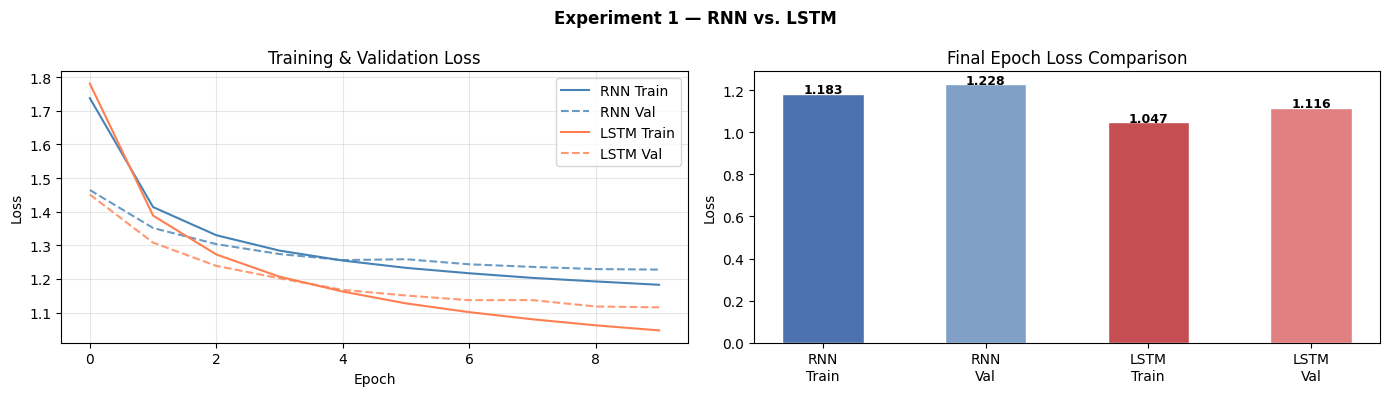

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Experiment 1 — RNN vs. LSTM', fontsize=12, fontweight='bold')

# Panel 1: overlaid loss curves
for label, tr, val, col in [
    ('RNN',  rnn_train_losses,  rnn_val_losses,  'steelblue'),
    ('LSTM', lstm_train_losses, lstm_val_losses, 'coral'),
]:
    axes[0].plot(tr,  label=f'{label} Train', color=col)
    axes[0].plot(val, label=f'{label} Val',   color=col, linestyle='--', alpha=0.8)
axes[0].set_title('Training & Validation Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: final-epoch bar chart
bar_labels = ['RNN\nTrain', 'RNN\nVal', 'LSTM\nTrain', 'LSTM\nVal']
bar_vals   = [rnn_train_losses[-1], rnn_val_losses[-1],
              lstm_train_losses[-1], lstm_val_losses[-1]]
bar_colors = ['#4C72B0','#80A0C8','#C44E52','#E08080']
bars = axes[1].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='white', width=0.5)
for b, v in zip(bars, bar_vals):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Final Epoch Loss Comparison'); axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('exp1_rnn_vs_lstm.png', dpi=100, bbox_inches='tight')
plt.show()

### 📝 Reflection Question 1

Answer in **2–4 sentences** in the cell below:

1. Which model reached a lower validation loss, and by approximately how much?
2. **Why** do LSTMs generally outperform vanilla RNNs on longer sequences?  
   *(Hint: think about the vanishing gradient problem and what gates the LSTM adds.)*

In [19]:
answer_q1 = """
The LSTM reached a lower validation loss of 1.116 compared to the RNN's 1.228, a difference of about 0.11.
LSTMs outperform vanilla RNNs on longer sequences because vanilla RNNs suffer from the vanishing gradient problem,
where gradients shrink to near zero as they travel back through many time steps, making it hard to learn
long range patterns. The LSTM's cell state acts as a long term memory that carries information across many
steps with minimal change, and its forget, input, and output gates control what gets remembered or discarded,
allowing gradients to flow more easily without vanishing.
"""
print(answer_q1)


The LSTM reached a lower validation loss of 1.116 compared to the RNN's 1.228, a difference of about 0.11.
LSTMs outperform vanilla RNNs on longer sequences because vanilla RNNs suffer from the vanishing gradient problem,
where gradients shrink to near zero as they travel back through many time steps, making it hard to learn
long range patterns. The LSTM's cell state acts as a long term memory that carries information across many
steps with minimal change, and its forget, input, and output gates control what gets remembered or discarded,
allowing gradients to flow more easily without vanishing.



### Experiment 2 — Effect of Sequence Length

Train the **LSTM** with three different sequence lengths.  All other hyperparameters stay the same.

> Longer sequences need more memory. Reduce `NUM_EPOCHS` to 5 if training is slow on CPU.

In [20]:
seq_lengths  = [16, 64, 128]
exp2_results = {}   # maps seq_len -> (train_losses, val_losses)

for sl in seq_lengths:
    print(f"\n── seq_length = {sl} " + "─" * 35)
    X_tr, y_tr = create_sequences(encoded_train, sl)
    X_vl, y_vl = create_sequences(encoded_val,   sl)
    tr_ld = DataLoader(TextDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
    vl_ld = DataLoader(TextDataset(X_vl, y_vl), batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMModel(vocab_size, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
    tr_l, vl_l = train_model(model, tr_ld, vl_ld, num_epochs=NUM_EPOCHS, lr=LR)
    exp2_results[sl] = (tr_l, vl_l)


── seq_length = 16 ───────────────────────────────────
  Epoch  1/10  |  train=1.7900  val=1.4450
  Epoch  2/10  |  train=1.3881  val=1.3000
  Epoch  3/10  |  train=1.2713  val=1.2483
  Epoch  4/10  |  train=1.2072  val=1.2095
  Epoch  5/10  |  train=1.1644  val=1.1854
  Epoch  6/10  |  train=1.1327  val=1.1618
  Epoch  7/10  |  train=1.1080  val=1.1551
  Epoch  8/10  |  train=1.0878  val=1.1441
  Epoch  9/10  |  train=1.0707  val=1.1390
  Epoch 10/10  |  train=1.0557  val=1.1363

── seq_length = 64 ───────────────────────────────────
  Epoch  1/10  |  train=1.8139  val=1.4805
  Epoch  2/10  |  train=1.4109  val=1.3307
  Epoch  3/10  |  train=1.2946  val=1.2579
  Epoch  4/10  |  train=1.2280  val=1.2158
  Epoch  5/10  |  train=1.1803  val=1.1892
  Epoch  6/10  |  train=1.1456  val=1.1779
  Epoch  7/10  |  train=1.1179  val=1.1595
  Epoch  8/10  |  train=1.0959  val=1.1494
  Epoch  9/10  |  train=1.0770  val=1.1406
  Epoch 10/10  |  train=1.0606  val=1.1343

── seq_length = 128 ───────

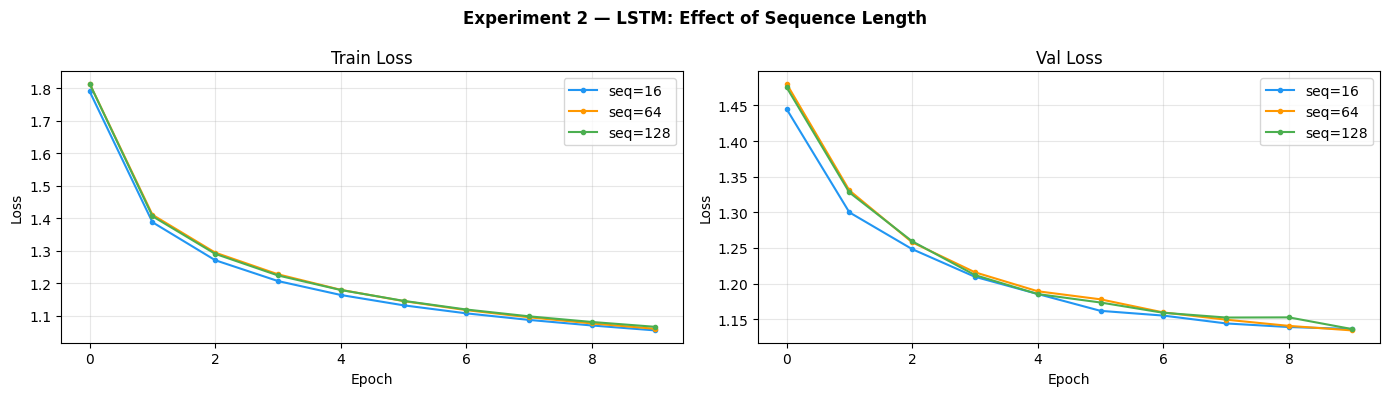

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Experiment 2 — LSTM: Effect of Sequence Length', fontsize=12, fontweight='bold')
palette = ['#2196F3', '#FF9800', '#4CAF50']

for ax_i, phase in enumerate(['Train', 'Val']):
    for i, sl in enumerate(seq_lengths):
        axes[ax_i].plot(exp2_results[sl][ax_i],
                        label=f'seq={sl}', color=palette[i], marker='o', markersize=3)
    axes[ax_i].set_title(f'{phase} Loss'); axes[ax_i].set_xlabel('Epoch')
    axes[ax_i].set_ylabel('Loss'); axes[ax_i].legend(); axes[ax_i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_seq_length.png', dpi=100, bbox_inches='tight')
plt.show()

### 📝 Reflection Question 2

Answer in **2–4 sentences**:

1. How did validation loss change as sequence length increased from 16 → 64 → 128?
2. What is the trade-off between very short and very long sequences during training?  
   *(Think about context window, gradient flow or memory/speed.)*

In [22]:
answer_q2 = """
1. Validation loss decreased slightly as sequence length increased from 16 to 64 to 128,
with all 3 ending near 1.136 by epoch 10. The differences were small, which suggests that
for this dataset and model size, sequence length had a small effect on final performance.

2. Short sequences train faster and have fewer gradient flow issues, but give the model
less context to learn from, limiting what patterns it can pick up. Long sequences provide
more context which helps the model learn longer range patterns, but take more memory and
can slow down training since each batch processes more time steps.
"""
print(answer_q2)


1. Validation loss decreased slightly as sequence length increased from 16 to 64 to 128,
with all 3 ending near 1.136 by epoch 10. The differences were small, which suggests that
for this dataset and model size, sequence length had a small effect on final performance.

2. Short sequences train faster and have fewer gradient flow issues, but give the model
less context to learn from, limiting what patterns it can pick up. Long sequences provide
more context which helps the model learn longer range patterns, but take more memory and
can slow down training since each batch processes more time steps.



## Part 7 — Text Generation with Temperature
Be careful with the `hidden` variable here !!!

After training, we **autoregressively** generate text:

```
seed → predict next char → append → predict next char → ...
```

### Temperature Controls Randomness

$$P_T(c_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

| Temperature `T` | Effect |
|----------------|--------|
| `T < 1` (e.g. 0.5) | Sharper probabilities → more repetitive, but coherent output|
| `T = 1.0` | Raw model distribution |
| `T > 1` (e.g. 2.0) | Flatter distribution → more diverse, potentially nonsensical output|

### TODO 7 — `generate_text`

In [23]:
def generate_text(model, seed_text, char_to_idx, idx_to_char,
                  length=300, temperature=1.0, device='cpu'):
    """
    Autoregressively generate `length` characters from a seed string.

    Args:
        model       : trained RNNModel or LSTMModel
        seed_text   (str)  : starting characters
        char_to_idx (dict) : char -> index  (from encode_text)
        idx_to_char (dict) : index -> char
        length      (int)  : number of NEW characters to generate
        temperature (float): sampling temperature  (must be > 0)
        device      (str)  : 'cpu' or 'cuda'
    Returns:
        generated (str): seed_text + newly generated characters
    """
    model.eval()
    # Encode seed (unknown chars get index 0)
    input_ids    = [char_to_idx.get(c, 0) for c in seed_text]
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    generated    = seed_text
    hidden       = None

    with torch.no_grad():
        # Warm up hidden state on the full seed
        _, hidden = model(input_tensor, hidden)

        # ── TODO 7 ──────────────────────────────────────────────────────────
        # Repeat `length` times:
        for _ in range(length):
            # Step 1: Get the last generated character's index as input
            next_input = torch.tensor([[char_to_idx.get(generated[-1], 0)]], dtype=torch.long).to(device)
            # Step 2: Forward pass through the model to get output logits
            output, hidden = model(next_input, hidden)    # output: (1, vocab_size)
            # Step 3: The output gives us the logits for the next character prediction. Apply temperature scaling.
            logits = output[0] / temperature
            # Step 4: Convert logits to probabilities using softmax
            probs  = torch.softmax(logits, dim=-1)
            # Step 5: Sample the next character's index from the probability distribution
            next_idx = torch.multinomial(probs, num_samples=1).item()
            # Step 6: Append the predicted character to `generated` and update `input_tensor` for the next iteration
            generated += idx_to_char[next_idx]
            # Step 7: Update input_tensor to contain the index of the newly generated character for the next iteration
            input_tensor = torch.tensor([[next_idx]], dtype=torch.long).to(device)
        # ────────────────────────────────────────────────────────────────────

    return generated

In [24]:
seed = "Once upon a time"
print(f"Seed: {repr(seed)}")
print(f"Generating 300 chars with LSTM (seq_length=64) at 3 temperatures...\n")

for T in [0.5, 1.0, 2.0]:
    print("=" * 62)
    print(f"  Temperature = {T}")
    print("=" * 62)
    out = generate_text(lstm_model, seed, char_to_idx, idx_to_char,
                        length=300, temperature=T, device=str(device))
    print(out)
    print()

Seed: 'Once upon a time'
Generating 300 chars with LSTM (seq_length=64) at 3 temperatures...

  Temperature = 0.5
Once upon a timeth ran around and started to share. He said, "I will not always things fit you."

The little boy was sad he had a big cheerful to the sky. They started to see the boy and she could he had found a big special many friends. He was so excited and continued the park, she was sad. He was so excited to pl

  Temperature = 1.0
Once upon a timetly. Sught. She saw a meturm curiengen. He looked up it.

He was now they and were playgily to help the grass. Once upon a time, there were two boy carefully showed the penful withiour the aric Sue. It was her ansune. You's trying the stust your!â€ 

The mouse stopped up and thought it sharive. He n

  Temperature = 2.0
Once upon a timeâ€ Tim's nommoth, â€œhis maman alh""'."

Yeqleacappesys? I" revened!"
Moine Tommy horka:'s jun!"

The lirp eaped the walk omsion sadion?".
The eat, they fley bleit them bulutsflowad. â€œLehint t

### 📝 Reflection Question 3

Answer in **3–5 sentences**:

1. Describe the qualitative difference in generated text at `T=0.5`, `T=1.0`, and `T=2.0`.
2. Which temperature produced the most readable / coherent output for you?
3. **Why** does increasing temperature make output more random?  
   *(Hint: what does dividing logits by a large number do to the softmax distribution?)*

In [25]:
answer_q3 = """
1. At T=0.5 the text was the most coherent and readable, using real words and mostly
correct sentence structure, although it was somewhat repetitive.
At T=1.0 the text started mixing real words with ones that were made up, becoming less coherent but more varied.
At T=2.0 the output was mostly nonsense, full of made up words and random characters with very
little content that's readible.

2. T=0.5 produced the most readable output, with real words and sentences that mostly
made sense even if the overall story was a bit repetitive.

3. Dividing logits by a large temp flattens the softmax distribution, making all
characters closer to equally likely. This means the model is less confident in its top
choice and more likely to pick unexpected characters, which leads to more random and
nonsense output. A small temp does the opposite, sharpening the distribution
so the model almost always picks its top choice, producing more repetitive but coherent text.
"""
print(answer_q3)


1. At T=0.5 the text was the most coherent and readable, using real words and mostly
correct sentence structure, although it was somewhat repetitive. 
At T=1.0 the text started mixing real words with ones that were made up, becoming less coherent but more varied. 
At T=2.0 the output was mostly nonsense, full of made up words and random characters with very
little content that's readible.

2. T=0.5 produced the most readable output, with real words and sentences that mostly
made sense even if the overall story was a bit repetitive.

3. Dividing logits by a large temp flattens the softmax distribution, making all
characters closer to equally likely. This means the model is less confident in its top
choice and more likely to pick unexpected characters, which leads to more random and
nonsense output. A small temp does the opposite, sharpening the distribution
so the model almost always picks its top choice, producing more repetitive but coherent text.



---
## Team Contributions <a id='team'></a>

> Each team member **must** write a paragraph (3–5 sentences) describing their contribution. Grades may differ for team members with unequal contributions. **Everyone should have written code.**

**Team Member 1 — [Patrick Elles]:**
*All*

---

**Team Member 2 — [Name]:**
*(Replace with your contribution)*

---
## AI Use Log <a id='ailog'></a>

If you used ChatGPT, Copilot, or any other AI tool, document every instance below. If none, write **"No AI tools used."**

| # | Tool | Prompt / Task | What it generated | What you changed |
|:---:|:---:|:---|:---|:---|
| — | — | No AI tools used. | — | — |